## MR4010 Navegacion autonoma

### ROI - Region of Interest (OpenCV)

Originalmente se utiliza esta imagen pero a color
](attachment:image.png)

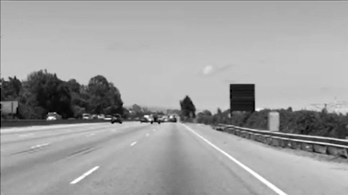

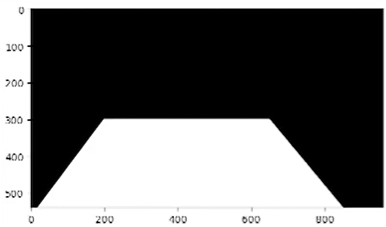

#### 1. LIBRERÍAS

In [2]:
# ==============================
# 1. LIBRERÍAS
# ==============================
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import cv2

#### 2.CARGA DE IMAGEN

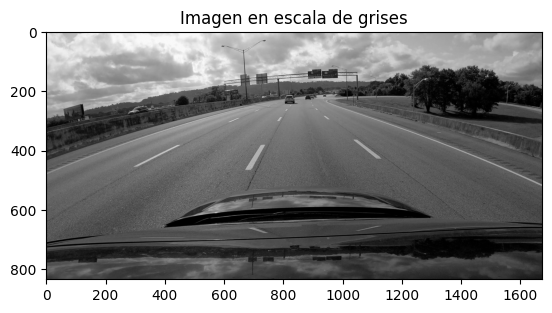

In [3]:
# Cargar imagen
IMAGE_PATH = "D:\ML\Projects\Project_5_MR4010.10_Navegacion\MR4010.10_Navegacion\data\Module1\Self_Driving_Car_ROADCAMERA.jpg"

img_bgr = cv2.imread(IMAGE_PATH)

if img_bgr is None:
    raise ValueError("No se pudo cargar la imagen")

# Convertir a escala de grises
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Mostrar imagen
plt.imshow(img_gray, cmap='gray')
plt.title("Imagen en escala de grises")
plt.show()

In [7]:
img_gray.shape

(835, 1674)

#### 3. DEFINICIÓN DE ROI (POLÍGONO)

[(0,835), (0,400), (550,250), (1050,250), (1674,400), (1674,835)]

THIS NUMBERS WERE CHANGED TO ACCOMODATE TO A NEW IMAGE

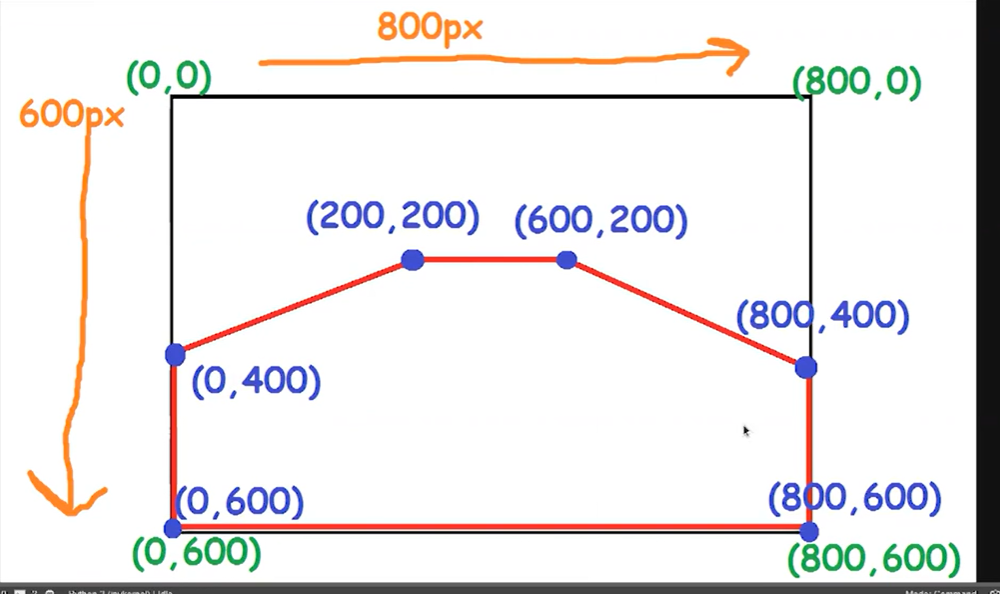

In [36]:
# Dimensiones
height, width = img_gray.shape

# Definir vértices del polígono ROI
vertices = np.array([[
    (int(width * 0.0), int(height * 0.75)),   # abajo izquierda
    (int(width * 0.35), int(height * 0.25)),  # arriba izquierda
    (int(width * 0.65), int(height * 0.25)),  # arriba derecha
    (int(width * 1.0), int(height * 0.75))    # abajo derecha
]], dtype=np.int32)

#### 4. CREAR MÁSCARA (ROI BLANCA)

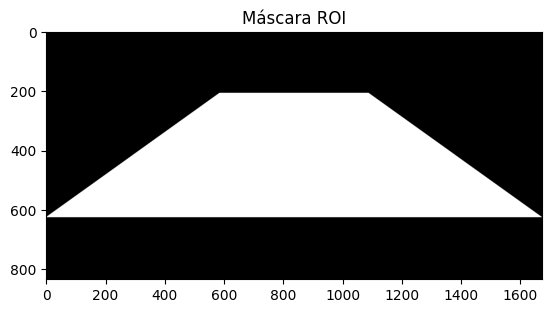

In [37]:
# Imagen negra del mismo tamaño
roi_mask = np.zeros_like(img_gray)

# Dibujar el polígono (blanco)
cv2.fillPoly(roi_mask, vertices, 255)

# Mostrar máscara
plt.imshow(roi_mask, cmap='gray')
plt.title("Máscara ROI")
plt.show()

#### 5. APLICAR ROI (OPERACIÓN AND)

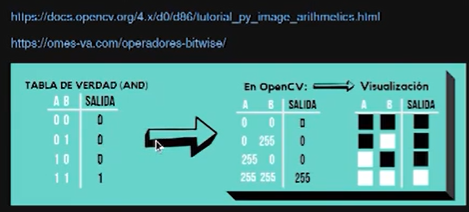

https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html

https://omes-va.com/operadores-bitwise/

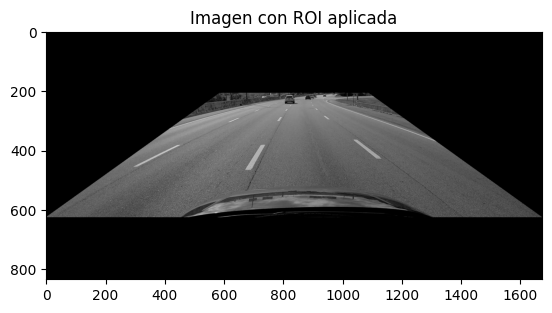

In [38]:
# Aplicar máscara con AND
img_roi = cv2.bitwise_and(img_gray, roi_mask)

# Mostrar resultado
plt.imshow(img_roi, cmap='gray')
plt.title("Imagen con ROI aplicada")
plt.show()

🧠 INTUICIÓN CLAVE

Negro (0) → se elimina

Blanco (255) → se conserva

👉 ROI = filtro espacial inteligente

#### BONUS (OPCIONAL – VISUALIZAR POLÍGONO SOBRE LA IMAGEN)

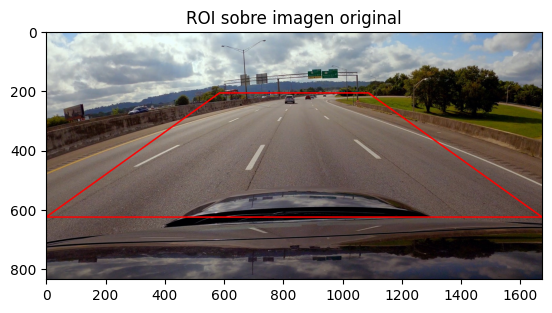

: 

In [ ]:
# Convertir a RGB para visualizar
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Dibujar polígono
cv2.polylines(img_rgb, vertices, isClosed=True, color=(255, 0, 0), thickness=3)

plt.imshow(img_rgb)
plt.title("ROI sobre imagen original")
plt.show()

🚀 RELACIÓN CON TU PROYECTO (MUY IMPORTANTE)

Este paso es CRÍTICO para:

Lane detection
Reducción de ruido
Performance en Jetson Nano
Robustez en visión autónoma

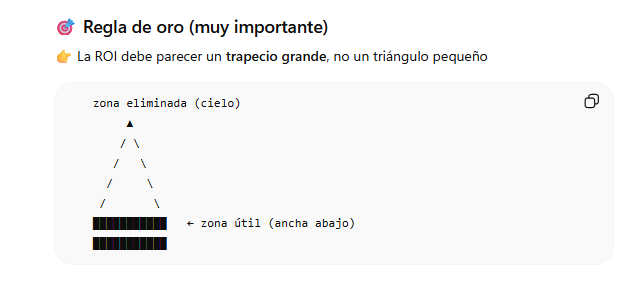